In [100]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# 表示設定（任意）
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [101]:
# === 入力先の指定 ===
# A) フォルダに .csv / .ods が入っている場合
DATA_DIR = "./data"   # ここをあなたのフォルダに変更

# B) 個別ファイルを明示指定する場合（使うならコメントを外す）
FILES = [
    # "/scratch/rs02358/ved_dissertation/CCEdit/outputs/tv2v/ALL-CCEdit.csv",
    "/scratch/rs02358/ved_dissertation/MotionDirector/outputs/inference/ALL-MotionDirector.csv",
]

# 必須列（列名はこの通りのスペル/大文字小文字で）
REQUIRED_COLS = ["video_id", "CLIP Score", "Temporal Consistency", "PickScore"]


In [102]:
def load_files(data_dir=None, files=None):
    paths = []
    if files is not None:
        paths = [Path(p) for p in files]
    elif data_dir is not None:
        data_dir = Path(data_dir)
        paths = list(data_dir.glob("*.csv")) + list(data_dir.glob("*.ods"))
    else:
        raise ValueError("Please set either DATA_DIR or FILES.")

    if not paths:
        raise FileNotFoundError("No .csv or .ods files found. Check your paths.")

    frames = []
    for p in paths:
        try:
            # もし .ods がカンマ区切りでない場合は delimiter= を調整
            df = pd.read_csv(p)
        except Exception as e:
            raise RuntimeError(f"Failed to read {p}: {e}")
        df["__source_file"] = str(p)
        frames.append(df)

    data = pd.concat(frames, ignore_index=True)

    # 必須列の確認
    missing = [c for c in REQUIRED_COLS if c not in data.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Found columns: {list(data.columns)}")

    # 数値列を numeric 化（不正値は NaN → drop）
    for col in ["CLIP Score", "Temporal Consistency", "PickScore"]:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    before = len(data)
    data = data.dropna(subset=["CLIP Score", "Temporal Consistency", "PickScore", "video_id"])
    after = len(data)
    if after < before:
        print(f"Dropped {before - after} rows due to missing/non-numeric required values.")

    # video_id を文字列に統一
    data["video_id"] = data["video_id"].astype(str)
    return data


In [103]:
FILES = globals().get("FILES", True)  # FILES を使っていなければ None
all_data = load_files(DATA_DIR, FILES)

print(f"Loaded {len(all_data)} rows from {all_data['__source_file'].nunique()} file(s).")
all_data.head()


Loaded 90 rows from 1 file(s).


,Timestamp,video_id,Filename,Prompt,Prior Noise,CLIP Score,PickScore,Temporal Consistency,Embedding Distance,Best,__source_file
0,2025-08-11 19:54:48,ApplyMakeup,A_focused_woman_carefully_applies_eyeliner_wit...,A focused woman carefully applies eyeliner wit...,0.1,0.3072,19.6431,0.9541,0.6873,NaN,/scratch/rs02358/ved_dissertation/MotionDirect...
1,2025-08-11 19:55:47,ApplyMakeup,A_focused_woman_carefully_applies_eyeliner_wit...,A focused woman carefully applies eyeliner wit...,0.3,0.2803,18.9778,0.9508,0.7142,NaN,/scratch/rs02358/ved_dissertation/MotionDirect...
2,2025-08-11 19:56:10,ApplyMakeup,A_focused_woman_carefully_applies_eyeliner_wit...,A focused woman carefully applies eyeliner wit...,0.5,0.2801,19.2174,0.9616,0.7149,NaN,/scratch/rs02358/ved_dissertation/MotionDirect...
3,2025-08-11 19:56:56,ApplyMakeup,A_focused_woman_carefully_applies_face_cream_w...,A focused woman carefully applies face cream w...,0.1,0.3078,18.7918,0.9510,0.6858,NaN,/scratch/rs02358/ved_dissertation/MotionDirect...
4,2025-08-11 19:57:24,ApplyMakeup,A_focused_woman_carefully_applies_face_cream_w...,A focused woman carefully applies face cream w...,0.3,0.3165,18.6360,0.9531,0.6769,XXX(motion-appearance),/scratch/rs02358/ved_dissertation/MotionDirect...


In [104]:
agg = (
    all_data
    .groupby("video_id", as_index=False)
    .agg({
        "CLIP Score": ["mean", "std"],
        "Temporal Consistency": ["mean", "std"],
        "PickScore": ["mean", "std"],
    })
)

# 列名をフラット化
agg.columns = [
    "video_id",
    "CLIP Score_mean", "CLIP Score_std",
    "Temporal Consistency_mean", "Temporal Consistency_std",
    "PickScore_mean", "PickScore_std"
]

# 読みやすく並べ替え
agg = agg.sort_values("video_id").reset_index(drop=True)
agg


,video_id,CLIP Score_mean,CLIP Score_std,Temporal Consistency_mean,Temporal Consistency_std,PickScore_mean,PickScore_std
0,ApplyMakeup,0.302378,0.021814,0.959444,0.012059,19.213589,0.663084
1,BoxingPunchingBag,0.341856,0.028637,0.968667,0.009899,19.823922,1.056983
2,BrushingTeeth,0.357733,0.034682,0.966556,0.011099,21.403322,1.029894
3,CleanAndJerk,0.312456,0.018795,0.953967,0.020093,20.239311,0.816187
4,Fencing,0.361744,0.036876,0.966700,0.011276,20.725067,0.969150
5,GolfSwing,0.335200,0.014434,0.931022,0.023756,20.892122,0.679315
6,HandstandWalking,0.307389,0.017388,0.970289,0.011721,20.428311,0.548663
7,HorseRiding,0.320911,0.017264,0.941178,0.018916,20.320322,0.601225
8,RockClimbingIndoor,0.315956,0.029332,0.950978,0.014643,18.835944,0.489480
9,SkateBoarding,0.306322,0.027633,0.942889,0.039919,20.175644,0.551894


In [105]:
def iqr(series):
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    return q3 - q1, q1, q3

results = {}

for metric_mean_col, label in [
    ("CLIP Score_mean", "CLIP Score (per-video mean)"),
    ("PickScore_mean", "PickScore (per-video mean)"),
]:
    vals = agg[metric_mean_col].values
    the_iqr, q1, q3 = iqr(vals)
    results[label] = {
        "N_videos": len(vals),
        "Min": float(np.min(vals)),
        "Q1": float(q1),
        "Median": float(np.median(vals)),
        "Mean": float(np.mean(vals)),
        "Q3": float(q3),
        "Max": float(np.max(vals)),
        "IQR": float(the_iqr),
    }

iqr_df = pd.DataFrame(results).T
iqr_df




,N_videos,Min,Q1,Median,Mean,Q3,Max,IQR
CLIP Score (per-video mean),10.0,0.302378,0.308656,0.318433,0.326194,0.340192,0.361744,0.031536
PickScore (per-video mean),10.0,18.835944,19.911853,20.279817,20.205756,20.650878,21.403322,0.739025


In [106]:
from pathlib import Path

OUTDIR = Path("./outputs_summary")
OUTDIR.mkdir(parents=True, exist_ok=True)

per_video_path = OUTDIR / "per_video_mean_sd.csv"
iqr_path = OUTDIR / "iqr_from_per_video_means.csv"

agg.to_csv(per_video_path, index=False)
iqr_df.to_csv(iqr_path)

print("Saved:")
print(per_video_path.resolve())
print(iqr_path.resolve())


Saved:
/user/HS402/rs02358/Documents/Dissertation/outputs_summary/per_video_mean_sd.csv
/user/HS402/rs02358/Documents/Dissertation/outputs_summary/iqr_from_per_video_means.csv


In [107]:
import re


def select_top4_per_video(df: pd.DataFrame, top_n: int = 2) -> pd.DataFrame:
    """
    各 video_id について：
      - 'CLIP Score' 上位 top_n 行
      - 'PickScore' 上位 top_n 行
      を取得し、重複（同一行）は統合。最大 2*top_n 本（重複時はそれ以下）。
      'selected_by' に選定理由（例: 'CLIP#1', 'PICK#2', 'CLIP#1 + PICK#1'）を付与。
    """
    records = []

    df = df.copy()
    df["_row_id"] = df.index  # ユニークID

    for vid, g in df.groupby("video_id", sort=False):
        g = g.copy()

        # NaN を落としてから上位抽出（安全対策）
        g_clip = g.dropna(subset=["CLIP Score"])
        g_pick = g.dropna(subset=["PickScore"])

        # CLIP/PICK 各上位 top_n
        clip_top = g_clip.nlargest(top_n, "CLIP Score") if not g_clip.empty else g.iloc[0:0]
        pick_top = g_pick.nlargest(top_n, "PickScore") if not g_pick.empty else g.iloc[0:0]

        # どの行がどの順位で選ばれたかを記録
        selected_tags: dict[int, str] = {}

        def _add_rows(rows: pd.DataFrame, tag_prefix: str):
            for rank, (_, r) in enumerate(rows.iterrows(), start=1):
                rid = int(r["_row_id"])
                tag = f"{tag_prefix}#{rank}"
                selected_tags[rid] = f"{selected_tags[rid]} + {tag}" if rid in selected_tags else tag

        _add_rows(clip_top, "CLIP")
        _add_rows(pick_top, "PICK")

        # 選ばれたユニーク行を抽出（最大4本、重複は自然に減る）
        chosen = g[g["_row_id"].isin(selected_tags.keys())].copy()
        if chosen.empty:
            continue

        chosen["video_id"] = chosen["video_id"].astype(str)
        chosen["selected_by"] = chosen["_row_id"].map(selected_tags)

        # 並べ替え用の一時列を作成
        def extract_min_rank(tag: str) -> int:
            nums = re.findall(r"#(\d+)", str(tag))
            return min(map(int, nums)) if nums else 99

        # rank（小さいほど上位）と、「CLIP/Pick のうち高い方の値」で降順
        chosen["_rank_priority"] = chosen["selected_by"].apply(extract_min_rank)
        chosen["_score_priority"] = chosen[["CLIP Score", "PickScore"]].max(axis=1)

        chosen = (chosen
                  .sort_values(by=["_rank_priority", "_score_priority"],
                               ascending=[True, False])
                  .reset_index(drop=True))

        # 出力列の順序（必要に応じて他の条件列を追加してください）
        base_cols = ["video_id", "CLIP Score", "PickScore", "selected_by"]
        base_cols = [c for c in base_cols if c in chosen.columns]
        other_cols = [c for c in chosen.columns if c not in base_cols + ["_row_id", "_rank_priority", "_score_priority"]]
        chosen = chosen[base_cols + other_cols + ["_row_id"]]

        records.append(chosen)

    out = pd.concat(records, ignore_index=True) if records else pd.DataFrame(columns=["video_id","CLIP Score","PickScore","selected_by"])
    return out

# 実行
top4 = select_top4_per_video(all_data, top_n=2)
display(top4.head(20))

# 保存
save_path = OUTDIR / "per_video_top4_clip2_pick2_dedup.csv"
top4.to_csv(save_path, index=False)
print(f"Saved: {save_path.resolve()}")



,video_id,CLIP Score,PickScore,selected_by,Timestamp,Filename,Prompt,Prior Noise,Temporal Consistency,Embedding Distance,Best,__source_file,_row_id
0,ApplyMakeup,0.3285,20.0700,CLIP#1 + PICK#1,2025-08-11 19:59:54,A_small_robot_carefully_applies_eyeliner_with_...,A small robot carefully applies eyeliner with ...,0.5,0.9621,0.6663,XXX,/scratch/rs02358/ved_dissertation/MotionDirect...,8
1,ApplyMakeup,0.3206,19.9158,CLIP#2 + PICK#2,2025-08-11 19:59:35,A_small_robot_carefully_applies_eyeliner_with_...,A small robot carefully applies eyeliner with ...,0.3,0.9886,0.6783,NaN,/scratch/rs02358/ved_dissertation/MotionDirect...,7
2,BoxingPunchingBag,0.4104,21.1758,CLIP#1 + PICK#1,2025-08-12 11:04:02,A_man_wearing_white_tank_top_practices_cooking...,A man wearing white tank top practices cooking...,0.1,0.9614,0.5826,XXX(motion-num),/scratch/rs02358/ved_dissertation/MotionDirect...,15
3,BoxingPunchingBag,0.3605,21.1078,CLIP#2 + PICK#2,2025-08-12 11:04:21,A_man_wearing_white_tank_top_practices_cooking...,A man wearing white tank top practices cooking...,0.3,0.9677,0.6351,NaN,/scratch/rs02358/ved_dissertation/MotionDirect...,16
4,BrushingTeeth,0.4077,22.5528,CLIP#1 + PICK#1,2025-08-12 11:08:56,A_crystal_skeleton_is_brushing_its_teeth_in_a_...,A crystal skeleton is brushing its teeth in a ...,0.1,0.9765,0.5886,XXX(Subject-num),/scratch/rs02358/ved_dissertation/MotionDirect...,18
5,BrushingTeeth,0.3585,22.2282,PICK#2,2025-08-12 11:11:21,A_young_girl_with_long_blonde_hair_is_brushing...,A young girl with long blonde hair is brushing...,0.3,0.9545,0.6362,NaN,/scratch/rs02358/ved_dissertation/MotionDirect...,25
6,BrushingTeeth,0.3925,22.2069,CLIP#2,2025-08-12 11:09:23,A_crystal_skeleton_is_brushing_its_teeth_in_a_...,A crystal skeleton is brushing its teeth in a ...,0.3,0.9613,0.6008,XXX(Subject-appearance),/scratch/rs02358/ved_dissertation/MotionDirect...,19
7,CleanAndJerk,0.3287,21.2953,CLIP#2 + PICK#1,2025-08-12 11:19:05,A_muscular_alien_performs_an_impressive_snatch...,A muscular alien performs an impressive snatch...,0.3,0.9773,0.6683,XXX,/scratch/rs02358/ved_dissertation/MotionDirect...,28
8,CleanAndJerk,0.3375,20.7466,CLIP#1,2025-08-12 11:18:51,A_muscular_alien_performs_an_impressive_snatch...,A muscular alien performs an impressive snatch...,0.1,0.9471,0.6551,NaN,/scratch/rs02358/ved_dissertation/MotionDirect...,27
9,CleanAndJerk,0.2834,21.2817,PICK#2,2025-08-12 11:21:25,A_strong_man_performs_an_impressive_snatch_lif...,"A strong man performs an impressive snatch, li...",0.5,0.9875,0.7152,XXX(background-appearance),/scratch/rs02358/ved_dissertation/MotionDirect...,35


Saved: /user/HS402/rs02358/Documents/Dissertation/outputs_summary/per_video_top4_clip2_pick2_dedup.csv


Saved: /user/HS402/rs02358/Documents/Dissertation/outputs_summary/boxplot_clip_score_ave.png


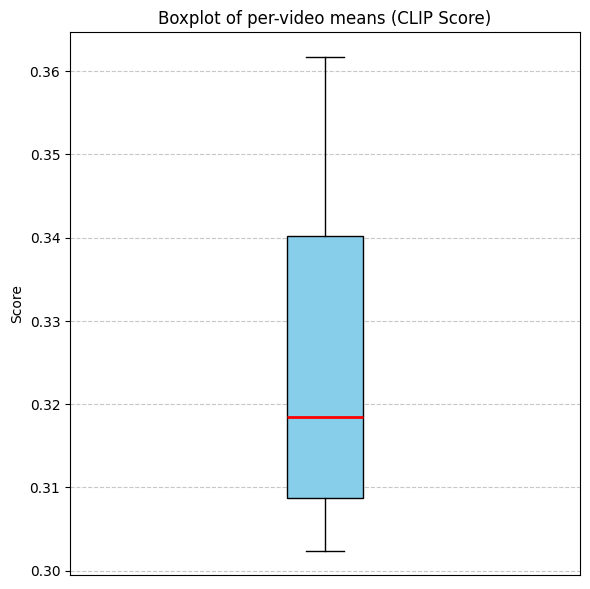

Saved: /user/HS402/rs02358/Documents/Dissertation/outputs_summary/boxplot_pickscore_ave.png


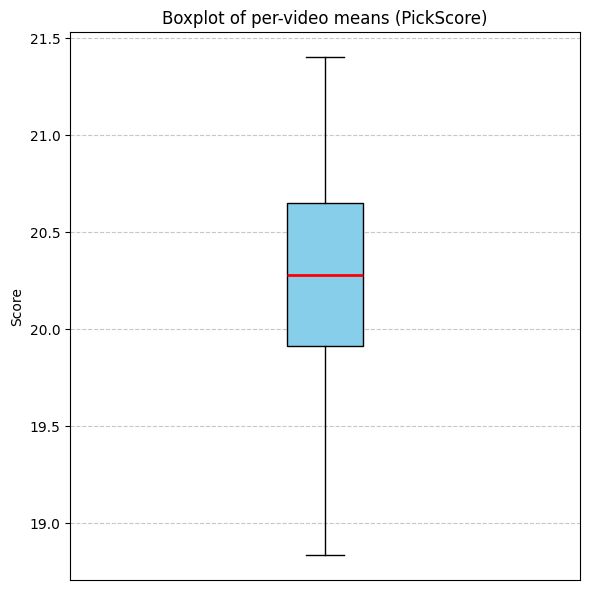

In [108]:
# --- IQR 可視化 (箱ひげ図, per-video mean の分布, 個別表示 + 保存) ---

metrics_to_plot = [
    ("CLIP Score_mean", "Boxplot of per-video means (CLIP Score)", "boxplot_clip_score_ave.png"),
    ("PickScore_mean", "Boxplot of per-video means (PickScore)", "boxplot_pickscore_ave.png")
]

for metric_col, title, filename in metrics_to_plot:
    vals = agg[metric_col].values

    plt.figure(figsize=(6, 6))
    plt.boxplot(vals, vert=True, patch_artist=True,
                boxprops=dict(facecolor="skyblue", color="black"),
                medianprops=dict(color="red", linewidth=2),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, color="gray", alpha=0.6))

    plt.title(title)
    plt.ylabel("Score")
    plt.xticks([])
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()

    # 保存
    save_path = OUTDIR / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path.resolve()}")

    # 表示
    plt.show()



/tmp/ipykernel_2356643/666775057.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_lists, labels=vids, showfliers=True)


Saved: /user/HS402/rs02358/Documents/Dissertation/outputs_summary/boxplot_AP_score_by_video.png


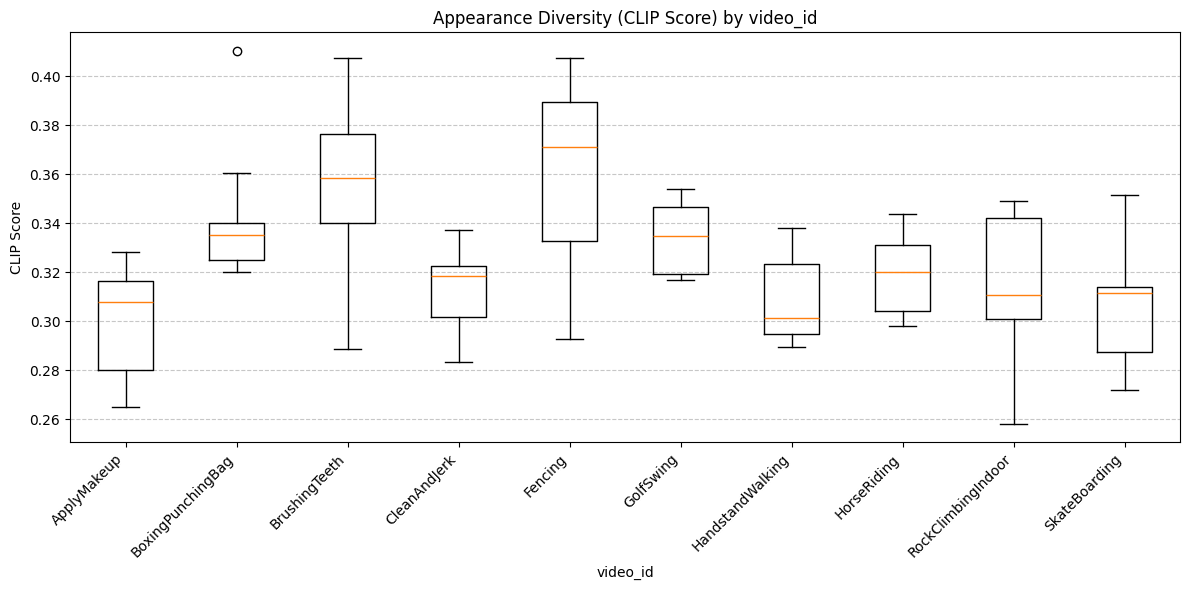

/tmp/ipykernel_2356643/666775057.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_lists, labels=vids, showfliers=True)


Saved: /user/HS402/rs02358/Documents/Dissertation/outputs_summary/boxplot_TC_score_by_video.png


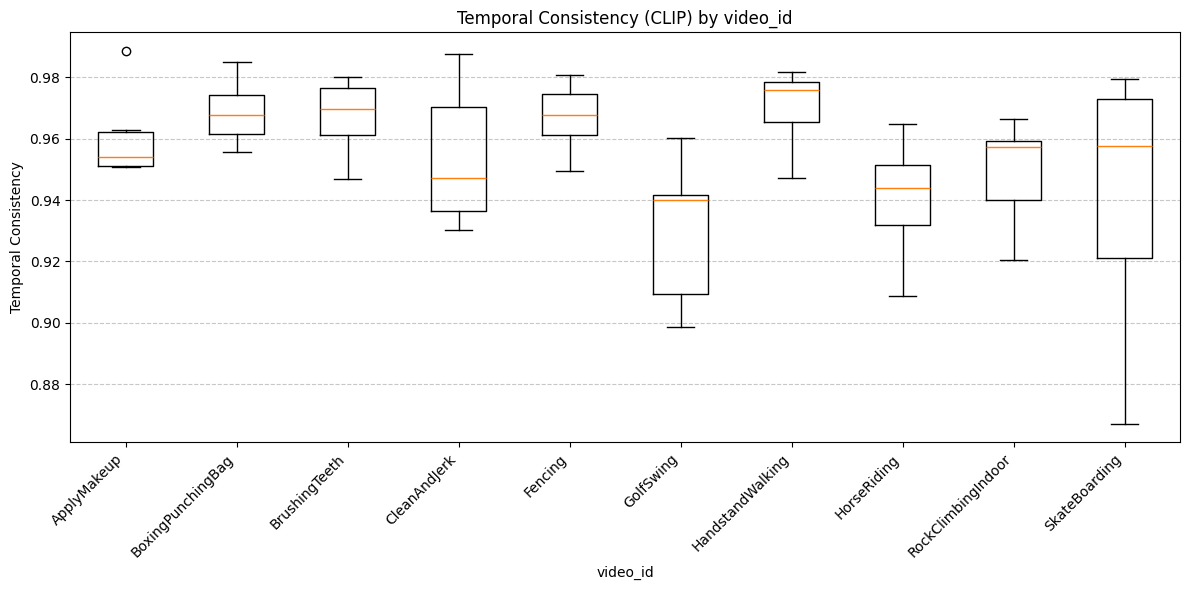

/tmp/ipykernel_2356643/666775057.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_lists, labels=vids, showfliers=True)


Saved: /user/HS402/rs02358/Documents/Dissertation/outputs_summary/boxplot_pickscore_by_video.png


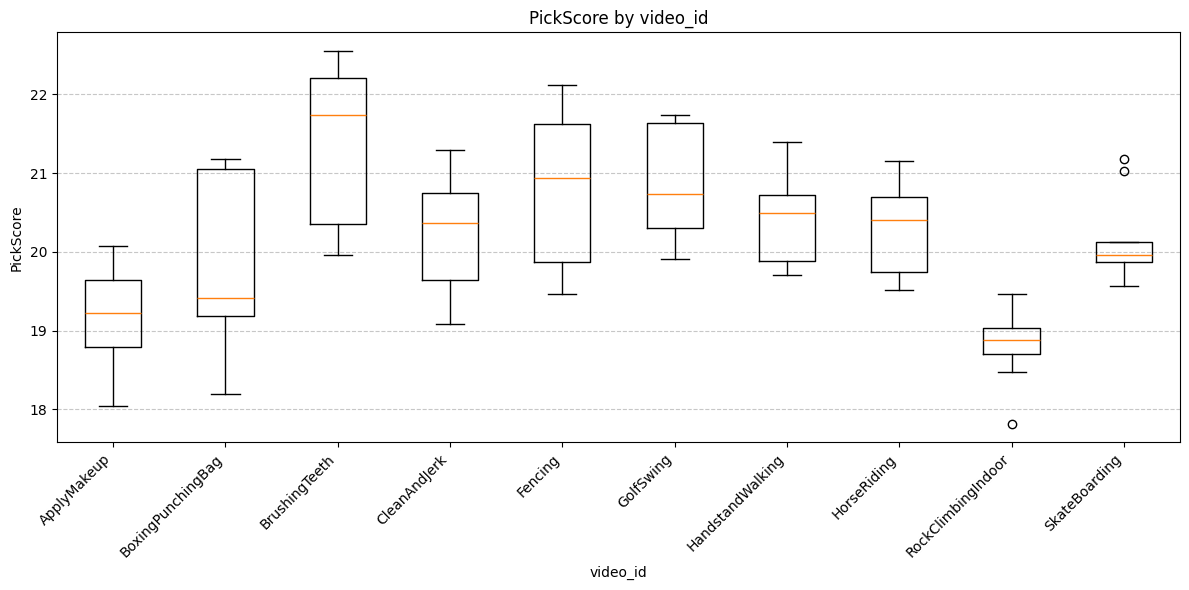

In [109]:
def boxplot_by_video(df, value_col, title, filename):
    vids = sorted(df["video_id"].unique(), key=lambda x: str(x))
    data_lists = [df.loc[df["video_id"] == v, value_col].values for v in vids]

    plt.figure(figsize=(12, 6))
    plt.boxplot(data_lists, labels=vids, showfliers=True)
    plt.xlabel("video_id")
    plt.ylabel(value_col)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()

    save_path = OUTDIR / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path.resolve()}")

    plt.show()

# Appearance Diversity（CLIP Score）
boxplot_by_video(all_data, "CLIP Score", "Appearance Diversity (CLIP Score) by video_id", "boxplot_AP_score_by_video.png")

# Temporal Consistency
boxplot_by_video(all_data, "Temporal Consistency", "Temporal Consistency (CLIP) by video_id", "boxplot_TC_score_by_video.png")

# PickScore
boxplot_by_video(all_data, "PickScore", "PickScore by video_id", "boxplot_pickscore_by_video.png")
